## Importando bibliotecas

In [122]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec         
from matplotlib.patches import FancyBboxPatch 
import seaborn as sns                          
import os

## Lendo os dados

In [123]:
rest_path = os.path.join(os.getcwd(), '..', 'data', 'rest_data_us_upd.csv')
rest = pd.read_csv(rest_path)

## Explorando os dados

In [124]:
# Visão geral
print(rest.info())
print('\n', rest.head(10))

# Estatísticas descritivas
print('\n', rest.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9651 entries, 0 to 9650
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           9651 non-null   int64 
 1   object_name  9651 non-null   object
 2   address      9651 non-null   object
 3   chain        9648 non-null   object
 4   object_type  9651 non-null   object
 5   number       9651 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 452.5+ KB
None

       id          object_name                          address  chain  \
0  11786  HABITAT COFFEE SHOP           3708 N EAGLE ROCK BLVD  False   
1  11787             REILLY'S                100 WORLD WAY 120  False   
2  11788       STREET CHURROS          6801 HOLLYWOOD BLVD 253  False   
3  11789    TRINITI ECHO PARK               1814 W SUNSET BLVD  False   
4  11790               POLLEN               2100 ECHO PARK AVE  False   
5  11791       THE SPOT GRILL              10004 NATIONAL BLVD  False

## Verificação de valores ausentes ou duplicados

In [125]:
# Verificar valores ausentes
print('Valores ausentes por coluna:')
print(rest.isnull().sum())

# Verificar duplicados
print('\n'+'Número de linhas duplicadas:')
print(rest.duplicated().sum())

Valores ausentes por coluna:
id             0
object_name    0
address        0
chain          3
object_type    0
number         0
dtype: int64

Número de linhas duplicadas:
0


In [126]:
# Visualizando os restaurantes com valores ausentes na coluna chain
print('Restaurantes com valores ausentes na coluna chain:')
print(rest[rest['chain'].isnull()])

# Visualizando o impacto dos valores ausentes
print(f'\nTotal de restaurantes: {len(rest)}')
print(f'Valores ausentes em chain: {rest["chain"].isnull().sum()}')
print(f'Porcentagem de ausentes: {(rest["chain"].isnull().sum() / len(rest)) * 100:.2f}%')

Restaurantes com valores ausentes na coluna chain:
         id              object_name               address chain object_type  \
7408  19194  TAQUERIA LOS 3 CARNALES  5000 E WHITTIER BLVD   NaN  Restaurant   
7523  19309     JAMMIN JIMMY'S PIZZA   1641 FIRESTONE BLVD   NaN       Pizza   
8648  20434    THE LEXINGTON THEATER          129 E 3RD ST   NaN  Restaurant   

      number  
7408      14  
7523       1  
8648      35  

Total de restaurantes: 9651
Valores ausentes em chain: 3
Porcentagem de ausentes: 0.03%


In [127]:
# Tratamento de ausentes: remoção das 3 linhas com 'chain' nulo
# Justificativa: 'chain' é booleana — preencher assumiria dados sem evidência.
# Com apenas 3 registros (~0,03% do total), a remoção não impacta a análise.
rest.dropna(subset=['chain'], inplace=True)
print(f'Linhas após remoção: {len(rest)}')

Linhas após remoção: 9648


In [128]:
# Checando categorias únicas
print(rest['object_type'].value_counts())
print('\n', rest['chain'].value_counts(dropna=False))

object_type
Restaurant    7253
Fast Food     1066
Cafe           435
Pizza          319
Bar            292
Bakery         283
Name: count, dtype: int64

 chain
False    5972
True     3676
Name: count, dtype: int64


## Análise exploratória

### Proporções de tipos de estabelecimento


In [129]:
# Calculando a proporção de cada tipo de estabelecimento
type_counts = rest['object_type'].value_counts()
type_proportions = (type_counts / len(rest) * 100).round(2)  # divide cada contagem pelo total, multiplica por 100 → percentual

# Exibindo os valores
print('Proporção por tipo de estabelecimento (%):')
print(type_proportions)


Proporção por tipo de estabelecimento (%):
object_type
Restaurant    75.18
Fast Food     11.05
Cafe           4.51
Pizza          3.31
Bar            3.03
Bakery         2.93
Name: count, dtype: float64


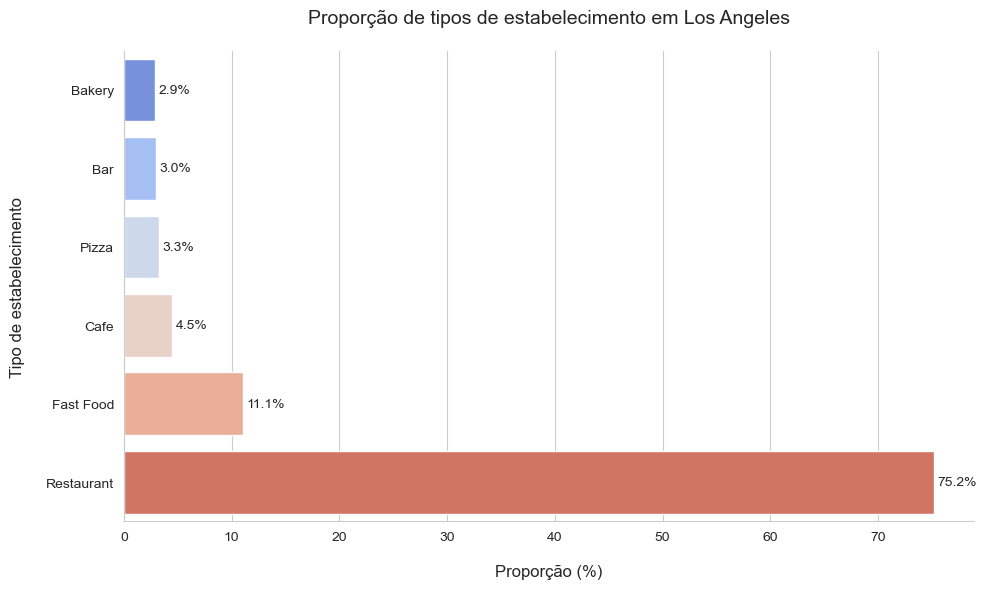

In [130]:
# Gráfico de barras horizontal — proporções por tipo de estabelecimento
# Escolha: barras horizontais são mais legíveis que pizza quando há múltiplas categorias,
# pois evitam distorções visuais entre fatias pequenas e facilitam a comparação de magnitudes.

# type_proportions é uma Series com index = tipo e valor = proporção (%).
# .reset_index() converte a Series em DataFrame com colunas nomeadas —
# formato exigido pelo Seaborn para identificar x e y separadamente.
type_prop_df = type_proportions.reset_index()
type_prop_df.columns = ['Tipo', 'Proporção (%)']

sns.set_style('whitegrid')  # tema visual: fundo branco com grade leve — padrão limpo do Seaborn
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=type_prop_df.sort_values('Proporção (%)'),  # ordena crescente → maior proporção no topo do barh
    y='Tipo',           # eixo Y categórico → Seaborn cria barras horizontais automaticamente
    x='Proporção (%)',  # eixo X numérico
    hue='Tipo',         # hue='Tipo': ativa a paleta por categoria — substitui o colormap manual do Matplotlib
    palette='coolwarm', # paleta divergente: tons frios (menor) → tons quentes (maior)
    legend=False,       # sem legenda — o eixo Y já identifica cada categoria
    ax=ax
)

# Rótulos de valor ao lado de cada barra
# ax.patches: lista de todos os retângulos desenhados — um por barra
for bar in ax.patches:
    ax.text(
        bar.get_width() + 0.3,              # posição X: logo após o fim da barra
        bar.get_y() + bar.get_height() / 2, # posição Y: centro vertical da barra
        f'{bar.get_width():.1f}%',          # texto: proporção com 1 casa decimal
        va='center', fontsize=10
    )

ax.set_title('Proporção de tipos de estabelecimento em Los Angeles', fontsize=14, pad=20)
ax.set_xlabel('Proporção (%)', fontsize=12, labelpad=15)
ax.set_ylabel('Tipo de estabelecimento', fontsize=12, labelpad=15)
ax.spines[['top', 'right']].set_visible(False)  # remove bordas → visual mais limpo

plt.tight_layout()
plt.show()

### Conclusão

- Os restaurantes representam a grande maioria dos estabelecimentos de alimentação em Los Angeles, seguidos de fast food. Os demais tipos (cafeterias, padarias, bares, etc.) têm participação significativamente menor. Isso indica um mercado dominado por formatos tradicionais de restaurante.


### Proporções de estabelecimentos de rede e independentes


In [131]:
# Calculando proporção de rede vs independente
chain_counts = rest['chain'].value_counts()
chain_labels = chain_counts.index.map({True: 'Rede', False: 'Independente'})  # .map(): substitui cada valor do índice pelo texto correspondente
chain_proportions = (chain_counts / len(rest) * 100).round(2)

print('Proporção → rede vs independente (%):')
for label, value in zip(chain_labels, chain_proportions.values):  # zip(): combina dois iteráveis em pares — a cada iteração, label e value avançam juntos
    print(f'  {label}: {value}%')

Proporção → rede vs independente (%):
  Independente: 61.9%
  Rede: 38.1%


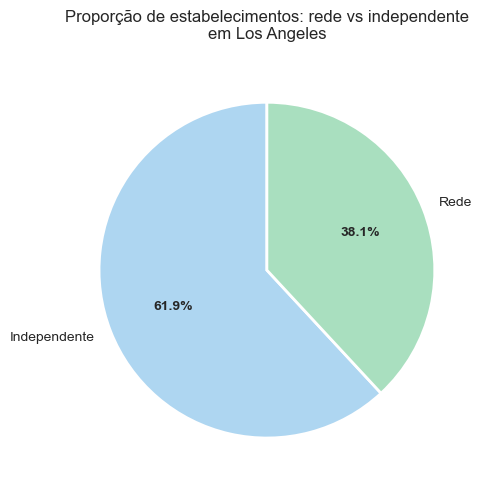

In [132]:
# Gráfico de pizza — rede vs independente
# Escolha: apenas 2 categorias tornam o gráfico de pizza ideal aqui,
# pois a comparação de proporção entre dois grupos é clara e sem distorção.

fig, ax = plt.subplots(figsize=(5, 5))

wedges, texts, autotexts = ax.pie( # retorna 3 objetos, variáveis, para personalizar o gráfico
    chain_proportions.values,
    labels=chain_labels,
    autopct='%1.1f%%', # formatando o texto automaticamente dentro das fatias
    startangle=90,
    colors=['#AED6F1', '#A9DFBF'],
    wedgeprops={'edgecolor': 'white', 'linewidth': 2} # propriedades visuais das fatias, adicionando uma borda branca entre elas
)

# Ajustando o estilo dos textos
for text in texts:
    text.set_fontsize(10)
for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')

ax.set_title('Proporção de estabelecimentos: rede vs independente\nem Los Angeles', fontsize=12, pad=15)

plt.tight_layout()
plt.show()


### Conclusão

- A maioria dos estabelecimentos em Los Angeles é **independente**, evidenciando um mercado com forte presença de negócios locais. Ainda assim, os estabelecimentos de rede representam uma parcela expressiva — o que é relevante para decisores que avaliam onde investir, já que redes tendem a ter maior poder de marca e padronização.


### Qual tipo de estabelecimento é típico para redes?


In [133]:
# Proporção de cada tipo dentro dos estabelecimentos de REDE
chain_type = (
    rest[rest['chain'] == True]['object_type']  # filtra só as linhas onde chain é True
    .value_counts(normalize=True)               # normalize=True: retorna proporções (0 a 1) em vez de contagens brutas
    .mul(100)                                   # .mul(100): multiplica toda a Series por 100 → converte para percentual
    .round(2)
)

# Proporção de cada tipo dentro dos INDEPENDENTES (para comparação)
indep_type = (
    rest[rest['chain'] == False]['object_type']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

# Consolidando em um DataFrame para visualização comparativa
comparison = pd.DataFrame({
    'Rede (%)': chain_type,
    'Independente (%)': indep_type
}).fillna(0)  

print(comparison)


             Rede (%)  Independente (%)
object_type                            
Bakery           7.70              0.00
Bar              2.09              3.60
Cafe             7.24              2.83
Fast Food       16.46              7.72
Pizza            4.16              2.78
Restaurant      62.35             83.07


/var/folders/fs/3hy1lgmd3p79yftgf7gp8gqh0000gn/T/ipykernel_13870/3874817860.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right', fontsize=10)


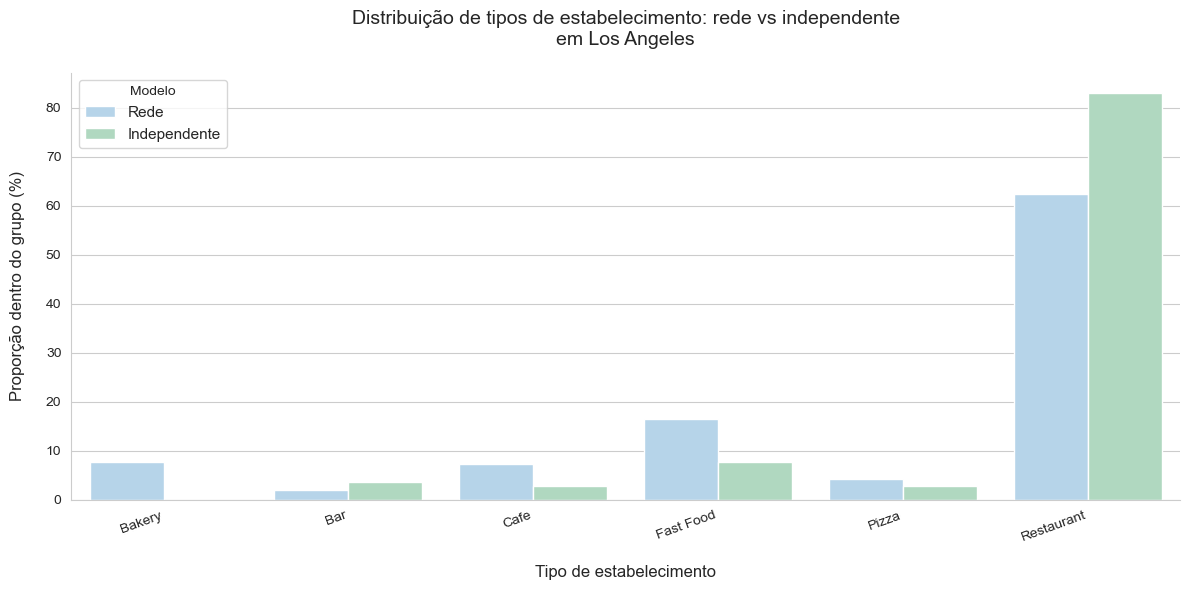

In [134]:
# Gráfico de barras agrupadas — tipo de estabelecimento por rede vs independente
# Escolha: barras agrupadas permitem comparar as duas categorias lado a lado
# para cada tipo de estabelecimento, revelando onde cada grupo é dominante.

# sns.barplot exige formato longo (long format): uma linha por observação.
# 'comparison' está em formato largo (wide) — uma coluna por grupo.
# .melt() reestrutura: cada linha vira um par (Tipo, Modelo, Proporção).
comparison_long = (
    comparison
    .reset_index()                                     # transforma índice (object_type) em coluna
    .rename(columns={'object_type': 'Tipo'})           # .rename(): nome mais legível para a coluna
    .melt(
        id_vars='Tipo',                                # coluna fixa: identificador do tipo
        value_vars=['Rede (%)', 'Independente (%)'],   # colunas a converter em linhas
        var_name='Modelo',                             # nova coluna com o nome do grupo
        value_name='Proporção (%)'                     # nova coluna com o valor percentual
    )
)
# Remove o sufixo ' (%)' para exibir 'Rede' e 'Independente' limpos na legenda
comparison_long['Modelo'] = comparison_long['Modelo'].str.replace(' (%)', '', regex=False)

sns.set_style('whitegrid')
fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=comparison_long,
    x='Tipo',                                                    # eixo X: tipos de estabelecimento
    y='Proporção (%)',                                           # eixo Y: proporção percentual dentro do grupo
    hue='Modelo',                                                # hue: agrupa Rede e Independente lado a lado automaticamente
    palette={'Rede': '#AED6F1', 'Independente': '#A9DFBF'},      # cores consistentes com o restante da análise
    ax=ax
)

ax.set_title('Distribuição de tipos de estabelecimento: rede vs independente\nem Los Angeles', fontsize=14, pad=20)
ax.set_xlabel('Tipo de estabelecimento', fontsize=12, labelpad=15)
ax.set_ylabel('Proporção dentro do grupo (%)', fontsize=12, labelpad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right', fontsize=10)
ax.legend(title='Modelo', fontsize=11)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

### Conclusão

- O **fast food** é o tipo de estabelecimento mais característico das redes — sua proporção dentro do grupo de redes é significativamente maior do que entre os independentes. Isso faz sentido: o modelo de franquia e rede é naturalmente compatível com operações padronizadas e de alto volume, que é a essência do fast food.
- Os **restaurantes** dominam entre os independentes, o que reforça que o formato tradicional de restaurante ainda é o principal veículo dos negócios locais em Los Angeles.


### O que caracteriza redes: muitos estabelecimentos com poucos assentos ou poucos estabelecimentos com muitos assentos?


In [135]:
# Estatísticas descritivas da coluna 'number' (assentos) por grupo
# A coluna 'number' representa a capacidade de assentos de cada estabelecimento
seats_stats = rest.groupby('chain')['number'].agg(['count', 'mean', 'median', 'std'])

# Renomeando índice e colunas para leitura mais clara
seats_stats.index = seats_stats.index.map({True: 'Rede', False: 'Independente'})
seats_stats.columns = ['Qtd. estabelecimentos', 'Média assentos', 'Mediana assentos', 'Desvio padrão']
seats_stats = seats_stats.round(1)

print(seats_stats)


              Qtd. estabelecimentos  Média assentos  Mediana assentos  \
chain                                                                   
Independente                   5972            46.2              28.0   
Rede                           3676            39.7              25.0   

              Desvio padrão  
chain                        
Independente           49.9  
Rede                   43.4  


/var/folders/fs/3hy1lgmd3p79yftgf7gp8gqh0000gn/T/ipykernel_13870/3005149299.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


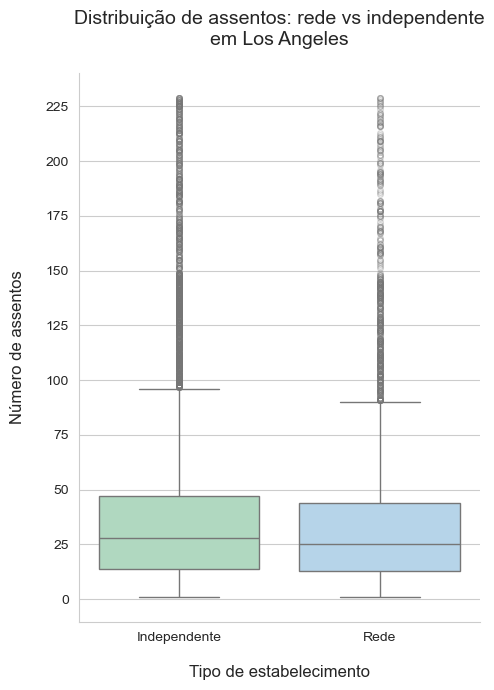

In [136]:
# Gráfico de boxplot — distribuição de assentos por grupo (rede vs independente)
# Escolha: boxplot é ideal para comparar distribuições, mostrando mediana,
# dispersão e outliers — essencial para entender 'muitos com poucos assentos' vs 'poucos com muitos'.

# Cria coluna de rótulo legível para o eixo X
# .map() substitui True/False pelo texto correspondente
rest_labeled = rest.copy()
rest_labeled['Grupo'] = rest_labeled['chain'].map({True: 'Rede', False: 'Independente'})

sns.set_style('whitegrid')
fig, ax = plt.subplots(figsize=(5, 7))

sns.boxplot(
    data=rest_labeled,
    x='Grupo',                                              # eixo X: agrupa automaticamente Rede e Independente
    y='number',                                             # eixo Y: número de assentos de cada estabelecimento
    palette={'Rede': '#AED6F1', 'Independente': '#A9DFBF'}, # cores por grupo — consistentes com o restante da análise
    flierprops=dict(marker='o', alpha=0.3, markersize=4),   # estilo dos outliers (pontos fora dos bigodes)
    ax=ax
)

ax.set_title('Distribuição de assentos: rede vs independente\nem Los Angeles', fontsize=14, pad=20)
ax.set_xlabel('Tipo de estabelecimento', fontsize=12, labelpad=15)
ax.set_ylabel('Número de assentos', fontsize=12, labelpad=15)
# np.arange(): gera ticks de 0 até o valor máximo do eixo Y de 25 em 25
ax.set_yticks(np.arange(0, ax.get_ylim()[1] + 1, 25))
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

### Conclusão

- Os dados mostram que redes têm **mediana de 25 assentos** por estabelecimento, contra **28 dos independentes** — ou seja, as unidades de rede são ligeiramente menores em capacidade. Porém, o ponto central da resposta está na **quantidade**: existem **3.676 estabelecimentos de rede** contra **5.972 independentes**, sendo que os independentes são em maior número absoluto mas operam com locais maiores em média.
- A conclusão é que **redes se caracterizam pelo modelo de muitos estabelecimentos com pequeno número de assentos** — consistente com o perfil de fast food identificado na análise anterior, onde a padronização e o alto volume de unidades compensam o tamanho reduzido de cada local.
- O desvio padrão menor das redes (43,4 vs 49,9) reforça isso: os estabelecimentos de rede são mais **homogêneos** em tamanho, enquanto os independentes apresentam maior variação — alguns podem ser pequenos botecos, outros grandes restaurantes.


### Número médio de assentos por tipo de estabelecimento

In [137]:
# Média de assentos por tipo de estabelecimento, ordenada de forma decrescente
avg_seats = (
    rest.groupby('object_type')['number']
    .mean()
    .round(1)
    .sort_values(ascending=False)
)

print('Número médio de assentos por tipo de estabelecimento:')
print(avg_seats.to_string())
print(f'\nTipo com maior média: {avg_seats.idxmax()} ({avg_seats.max()} assentos)')


Número médio de assentos por tipo de estabelecimento:
object_type
Restaurant    48.0
Bar           44.8
Fast Food     31.8
Pizza         28.5
Cafe          25.0
Bakery        21.8

Tipo com maior média: Restaurant (48.0 assentos)


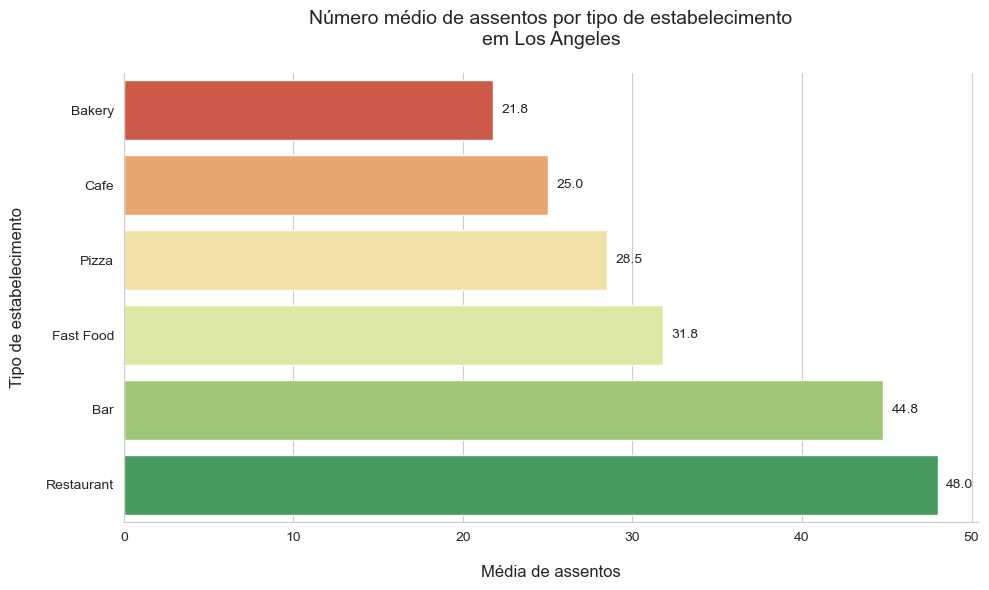

In [138]:
# Gráfico de barras horizontais — média de assentos por tipo de estabelecimento
# Escolha: barras horizontais facilitam a leitura dos rótulos de cada categoria
# e permitem comparar visualmente qual tipo tem maior capacidade média.

# .reset_index() converte a Series (index = tipo, valor = média) em DataFrame com colunas —
# formato exigido pelo Seaborn para identificar x e y separadamente.
avg_seats_df = avg_seats.reset_index()
avg_seats_df.columns = ['Tipo', 'Média de assentos']

sns.set_style('whitegrid')
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=avg_seats_df.sort_values('Média de assentos'),  # ordem crescente → maior média no topo do barh
    y='Tipo',                                             # eixo Y categórico → barras horizontais automáticas
    x='Média de assentos',                               # eixo X numérico
    hue='Tipo',                                          # hue='Tipo': ativa a paleta por categoria
    palette='RdYlGn',                                    # escala de cores: vermelho (menor) → verde (maior)
    legend=False,                                        # sem legenda — eixo Y já identifica cada categoria
    ax=ax
)

# Rótulos de valor ao lado de cada barra
# ax.patches: lista de todos os retângulos desenhados pelo Seaborn — um por barra
for bar in ax.patches:
    ax.text(
        bar.get_width() + 0.5,              # posição X: logo após o fim da barra
        bar.get_y() + bar.get_height() / 2, # posição Y: centro vertical da barra
        f'{bar.get_width():.1f}',           # texto: valor numérico com 1 casa decimal
        va='center', fontsize=10
    )

ax.set_title('Número médio de assentos por tipo de estabelecimento\nem Los Angeles', fontsize=14, pad=20)
ax.set_xlabel('Média de assentos', fontsize=12, labelpad=15)
ax.set_ylabel('Tipo de estabelecimento', fontsize=12, labelpad=15)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

### Conclusão

- Em média, os **restaurantes** têm o maior número de assentos entre todos os tipos de estabelecimento em Los Angeles, seguidos de **bares** e **padarias**. Isso faz sentido: restaurantes tradicionais dependem de capacidade de atendimento presencial para geração de receita, enquanto fast foods e cafeterias tendem a operar com espaços menores e maior rotatividade.
- O resultado reforça a análise anterior: as redes, que são dominadas por fast foods, operam com menor capacidade por unidade (menor média de assentos), enquanto os restaurantes independentes — que em sua maioria são do tipo "restaurant" — tendem a ter espaços maiores.


## Trabalhando com os endereços

### Extração do nome da rua

In [139]:
# Extraindo o nome da rua a partir da coluna 'address':
# 1. Remover o número do imóvel (dígitos no início)
# 2. Remover informações de unidade/apartamento no final (STE, UNIT, APT, # ou número solto)
rest['street_name'] = (
    rest['address']
    .str.replace(r'^\d+\s+', '', regex=True)                              # removendo número do imóvel
    .str.replace(r'\s+(?:STE|UNIT|APT|#)\s*\S+.*$', '', regex=True)      # removendo suite/unidade com prefixo
    .str.replace(r'\s+\d+\s*$', '', regex=True)                           # removendo número solto no final
    .str.strip()
)

print('Exemplos de extração:')
print(rest[['address', 'street_name']].head(10).to_string(index=False))

Exemplos de extração:
                        address       street_name
         3708 N EAGLE ROCK BLVD N EAGLE ROCK BLVD
              100 WORLD WAY 120         WORLD WAY
        6801 HOLLYWOOD BLVD 253    HOLLYWOOD BLVD
             1814 W SUNSET BLVD     W SUNSET BLVD
             2100 ECHO PARK AVE     ECHO PARK AVE
            10004 NATIONAL BLVD     NATIONAL BLVD
              100 WORLD WAY 126         WORLD WAY
          3500 W 6TH ST STE 226          W 6TH ST
3027 N SAN FERNANDO RD UNIT 103 N SAN FERNANDO RD
           3707 N CAHUENGA BLVD   N CAHUENGA BLVD


### Dez ruas com o maior número de restaurantes

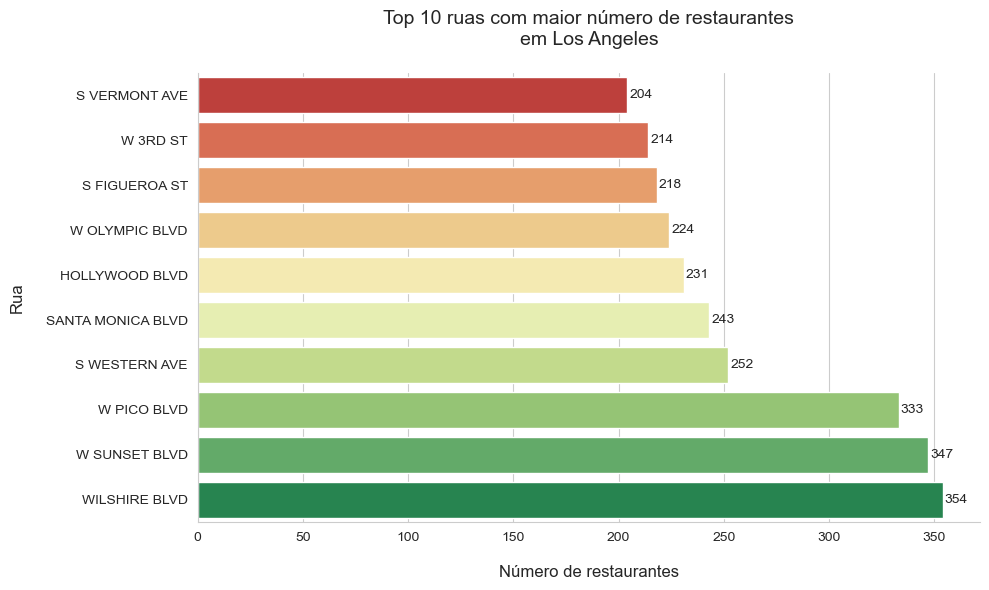

In [140]:
# Top 10 ruas com maior número de restaurantes
# Escolha: barras horizontais facilitam a leitura dos nomes de rua e permitem
# comparar rapidamente o volume de estabelecimentos por via.
top10_streets = (
    rest['street_name']
    .value_counts()
    .head(10)
    .sort_values()   # ordem crescente → rua com mais restaurantes fica no topo do gráfico horizontal
)

# .reset_index() converte a Series (index = rua, valor = contagem) em DataFrame com colunas
# nomeadas — formato exigido pelo Seaborn para identificar x e y separadamente.
top10_streets_df = top10_streets.reset_index()
top10_streets_df.columns = ['Rua', 'Nº de restaurantes']

sns.set_style('whitegrid')
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=top10_streets_df.sort_values('Nº de restaurantes'),  # ordem crescente → maior no topo
    y='Rua',                    # eixo Y categórico → barras horizontais automáticas
    x='Nº de restaurantes',     # eixo X numérico
    hue='Rua',                  # hue='Rua': ativa a paleta por categoria
    palette='RdYlGn',           # escala de cores: vermelho (menos restaurantes) → verde (mais)
    legend=False,               # sem legenda — eixo Y já identifica cada rua
    ax=ax
)

# Rótulos de valor ao lado de cada barra
for bar in ax.patches:
    ax.text(
        bar.get_width() + 1,                # posição X: logo após o fim da barra
        bar.get_y() + bar.get_height() / 2, # posição Y: centro vertical da barra
        str(int(bar.get_width())),          # texto: contagem como inteiro
        va='center', fontsize=10
    )

ax.set_title('Top 10 ruas com maior número de restaurantes\nem Los Angeles', fontsize=14, pad=20)
ax.set_xlabel('Número de restaurantes', fontsize=12, labelpad=15)
ax.set_ylabel('Rua', fontsize=12, labelpad=15)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

### Ruas com apenas um restaurante

In [141]:
# Número de ruas com apenas um restaurante
street_counts = rest['street_name'].value_counts()
single_restaurant_streets = (street_counts == 1).sum()

print(f'Total de ruas únicas: {len(street_counts)}')
print(f'Ruas com apenas 1 restaurante: {single_restaurant_streets}')
print(f'Proporção: {single_restaurant_streets / len(street_counts) * 100:.1f}% das ruas listadas possuem apenas um restaurante')

Total de ruas únicas: 1294
Ruas com apenas 1 restaurante: 822
Proporção: 63.5% das ruas listadas possuem apenas um restaurante


### Distribuição de assentos nas ruas com muitos restaurantes

In [142]:
# Estatísticas de assentos por rua do top 10
top10_names = top10_streets.index.tolist()  # nomes das 10 ruas com mais restaurantes

top10_data = rest[rest['street_name'].isin(top10_names)]

seats_by_street = (
    top10_data.groupby('street_name')['number']
    .agg(restaurantes='count', media='mean', mediana='median', desvio_padrao='std')
    .round(1)
    .sort_values('restaurantes', ascending=False)
)

print('Distribuição de assentos nas 10 ruas com mais restaurantes:')
print(seats_by_street.to_string())

Distribuição de assentos nas 10 ruas com mais restaurantes:
                   restaurantes  media  mediana  desvio_padrao
street_name                                                   
WILSHIRE BLVD               354   53.3     36.0           51.9
W SUNSET BLVD               347   48.9     34.0           50.2
W PICO BLVD                 333   39.7     26.0           41.2
S WESTERN AVE               252   41.8     28.0           42.3
SANTA MONICA BLVD           243   36.1     22.0           41.6
HOLLYWOOD BLVD              231   53.9     33.0           56.0
W OLYMPIC BLVD              224   49.9     28.0           56.3
S FIGUEROA ST               218   47.2     25.5           49.3
W 3RD ST                    214   38.3     26.0           38.4
S VERMONT AVE               204   44.0     28.0           47.8


/var/folders/fs/3hy1lgmd3p79yftgf7gp8gqh0000gn/T/ipykernel_13870/3796319232.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/fs/3hy1lgmd3p79yftgf7gp8gqh0000gn/T/ipykernel_13870/3796319232.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order, rotation=25, ha='right', fontsize=9)  # rótulos rotacionados para evitar sobreposição


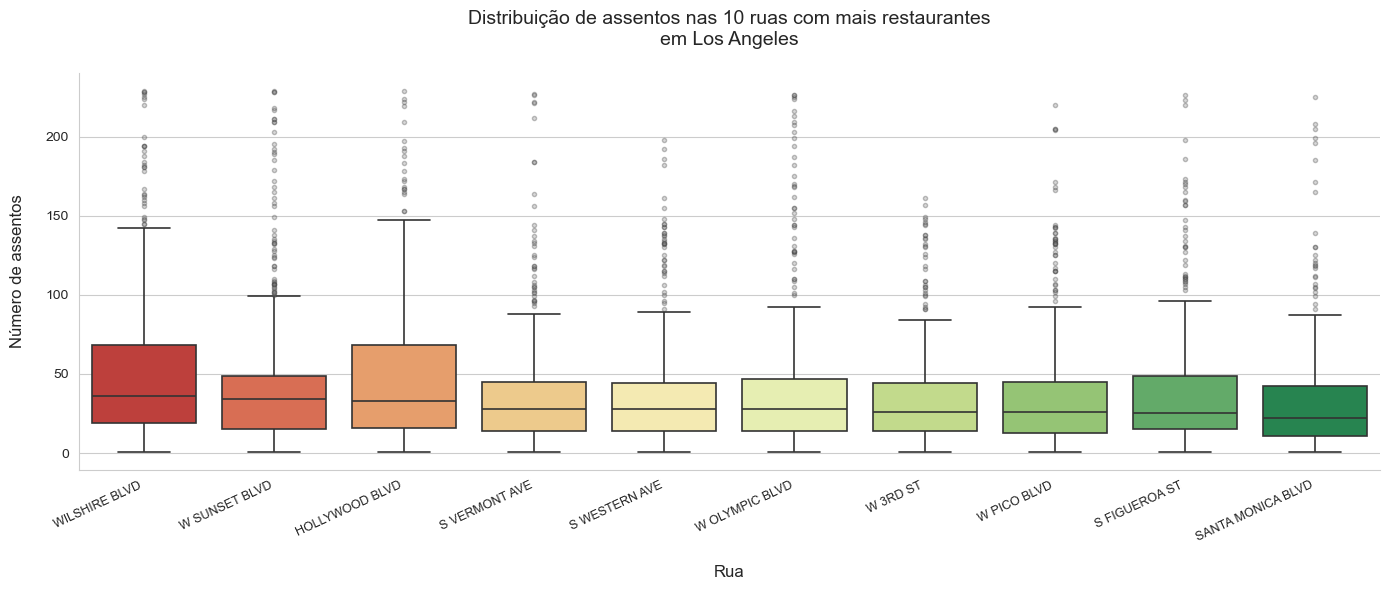

In [143]:
# Boxplot — distribuição de assentos por rua (top 10)
# Escolha: boxplot é ideal para comparar distribuições entre grupos, exibindo mediana,
# dispersão e outliers de cada rua — revela se os estabelecimentos são homogêneos ou variados em tamanho.
# Ordenado pela mediana para facilitar a comparação visual entre as ruas.

order = (
    top10_data.groupby('street_name')['number']
    .median()
    .sort_values(ascending=False)
    .index.tolist()  # .tolist(): converte índice em lista Python — formato exigido pelo parâmetro 'order'
)

sns.set_style('whitegrid')
fig, ax = plt.subplots(figsize=(14, 6))

sns.boxplot(
    data=top10_data,      # DataFrame completo — o Seaborn filtra e agrupa por 'street_name' internamente
    x='street_name',      # eixo X: nome da rua (categórico)
    y='number',           # eixo Y: número de assentos (numérico)
    order=order,          # order: define a sequência de exibição das ruas (maior mediana à esquerda)
    palette='RdYlGn',     # paleta divergente: vermelho (menor mediana) → verde (maior mediana)
    linewidth=1.2,        # linewidth: espessura das linhas da caixa e bigodes
    flierprops=dict(marker='o', markersize=3, alpha=0.3, markerfacecolor='gray'),  # estilo dos outliers
    ax=ax
)

ax.set_title('Distribuição de assentos nas 10 ruas com mais restaurantes\nem Los Angeles', fontsize=14, pad=20)
ax.set_xlabel('Rua', fontsize=12, labelpad=15)
ax.set_ylabel('Número de assentos', fontsize=12, labelpad=15)
ax.set_xticklabels(order, rotation=25, ha='right', fontsize=9)  # rótulos rotacionados para evitar sobreposição
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

### Conclusão

- **Medianas baixas e consistentes**: a mediana de assentos nas ruas com mais restaurantes gira em torno de **22 a 36 assentos** em todas elas, indicando que a maioria dos estabelecimentos é de pequeno porte, independente da rua.
- **Alta presença de outliers**: todas as ruas apresentam muitos pontos acima do bigode superior — estabelecimentos com 150–225 assentos. Isso mostra que convivem, nas mesmas ruas, pequenos botecos e grandes restaurantes.
- **Wilshire Blvd e Hollywood Blvd** se destacam com as medianas mais altas (~36 e ~33 assentos) e maior variação (desvio padrão > 50), sugerindo perfil mais diversificado — de fast foods pequenos a restaurantes maiores.
- **Santa Monica Blvd e W Pico Blvd** têm as medianas mais baixas (~22 e ~26 assentos) e desvio padrão menor, indicando predominância de estabelecimentos menores e mais homogêneos — perfil mais voltado a fast food e consumo rápido.

## Conclusão Geral e Recomendações

### Síntese dos dados

A análise do mercado de restaurantes em Los Angeles revelou um cenário bem definido:

| Aspecto | Dado-chave |
|---|---|
| Tipo dominante | **Restaurant** (~maioria absoluta dos estabelecimentos) |
| Modelo dominante | **Independente** (~62% dos estabelecimentos) |
| Mediana de assentos — rede | **25 assentos** |
| Mediana de assentos — independente | **28 assentos** |
| Rua com mais restaurantes | **Wilshire Blvd** (354 restaurantes) |
| Ruas com apenas 1 restaurante | **63,5%** das ruas únicas |

---

### Tipo de estabelecimento recomendado

O formato **restaurante tradicional** (*Restaurant*) é o mais consolidado no mercado de LA — domina tanto em quantidade absoluta quanto na preferência dos independentes. Isso indica alta demanda do público por esse formato, mas também **alta competição**.

Para um novo entrante, as alternativas com menor saturação e nichos mais definidos são mais interessantes:
- **Café/Cafeteria**: baixa presença relativa, menor exigência de capital inicial, e forte demanda em regiões de escritórios e universidades.
- **Bakery (padaria)**: boa média de assentos (acima de fast food), segmento diferenciado e com menor concorrência de redes.
- **Bar**: alta média de assentos, ticket médio elevado — porém exige localização estratégica.

---

### Número de assentos recomendado

- A maioria dos estabelecimentos nas ruas mais movimentadas opera com **22 a 36 assentos** (faixa da mediana) — tamanho ideal para controle de custos e rotatividade.
- Estabelecimentos com mais de 100 assentos existem (outliers), mas são exceção — exigem maior capital e gestão mais complexa.
- **Recomendação**: iniciar com **30 a 50 assentos**, equilibrando capacidade de atendimento, custo operacional e flexibilidade para crescimento.

---

### Possibilidade de desenvolver uma rede

Os dados indicam que **desenvolver uma rede é viável**, mas requer uma estratégia clara:

**Perfil favorável para rede:**
- Fast food é o tipo mais comum entre redes — padronização e alto volume compensam margens menores por unidade.
- Redes operam com **menos assentos por unidade** e **maior homogeneidade** (desvio padrão menor), o que facilita replicação do modelo.
- As ruas com mais restaurantes (Wilshire, Sunset, Pico) concentram centenas de estabelecimentos — a **presença de rede nessas vias é estratégica** para visibilidade de marca.

**Estratégia sugerida:**
1. Iniciar como **independente** em uma rua de alta concentração (ex: Wilshire Blvd ou W Sunset Blvd) para validar o modelo.
2. Padronizar operação: cardápio enxuto, processos replicáveis, 30–50 assentos.
3. Expandir para ruas secundárias onde **63,5% das ruas têm apenas 1 restaurante** — há oportunidade de ser o estabelecimento referência em vias menos exploradas.
4. Considerar o modelo **fast food ou café** para escala de rede, dado o perfil comprovado das redes atuais.


## Apresentação para Investidores

Dashboard de uma página gerado com Matplotlib, exportado em PDF e disponibilizado via link de armazenamento em nuvem.


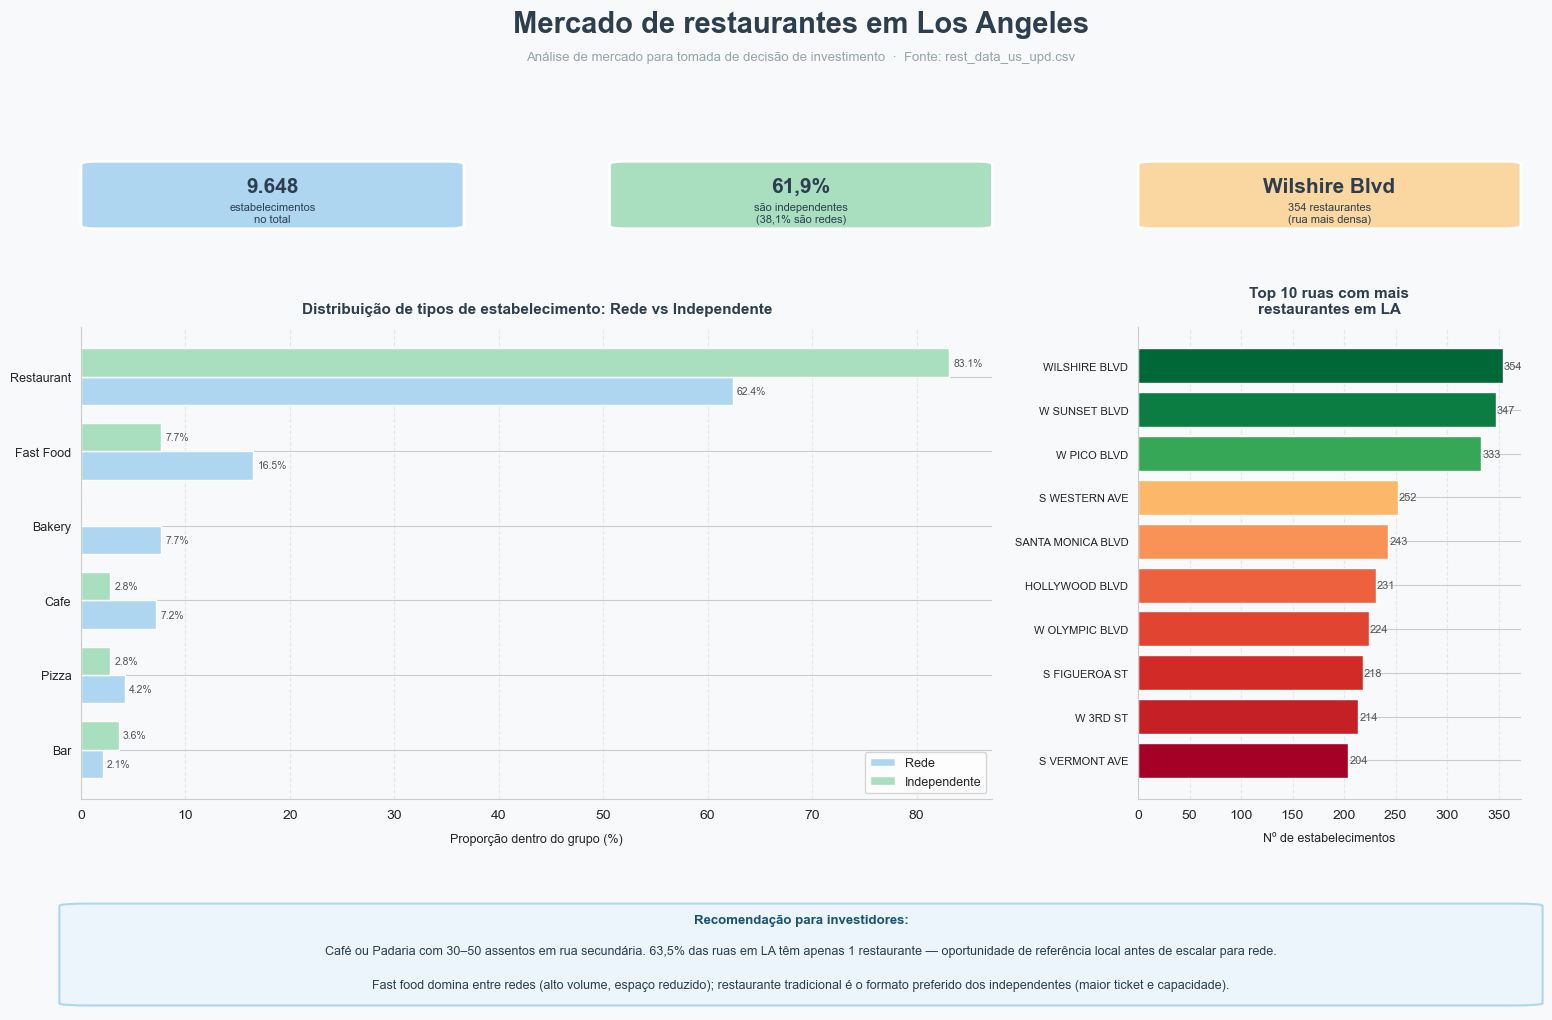

In [144]:

# Apresentação para investidores — dashboard de uma página exportado em PDF
# Usamos matplotlib.gridspec para dividir a figura em regiões independentes,
# permitindo combinar KPIs, dois gráficos e um bloco de texto em uma única página.

## import matplotlib.gridspec as gridspec     
## from matplotlib.patches import FancyBboxPatch   
## as bibliotecas acima foram importadas para uso neste momento
# gridspec: módulo do matplotlib que divide a figura em uma grade de subplots com tamanhos personalizados
# FancyBboxPatch: patch (forma geométrica) retangular com bordas arredondadas, usado para construir as caixas dos KPIs


# ── DADOS PARA OS GRÁFICOS ───────────────────────────────────────────────────

# Gráfico 1: proporção de cada tipo de estabelecimento dentro do grupo Rede
chain_type = (
    rest[rest['chain'] == True]['object_type']    # filtrando apenas os estabelecimentos de rede
    .value_counts(normalize=True)                 # normalize=True: retorna proporções (0 a 1) em vez de contagens brutas
    .mul(100)                                     # convertendo para percentual multiplicando por 100
    .round(1)                                     # arredondando para 1 casa decimal
)

# Proporção de cada tipo dentro do grupo Independente (para comparação lado a lado)
indep_type = (
    rest[rest['chain'] == False]['object_type']   # filtrando apenas os independentes
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

# Consolidando as duas Series em um DataFrame com uma coluna para cada grupo
comparison = (
    pd.DataFrame({'Rede (%)': chain_type, 'Independente (%)': indep_type})
    .fillna(0)                                    # tipos ausentes em um grupo recebem 0 em vez de NaN
    .sort_values('Rede (%)', ascending=True)      # ordenação crescente pelo percentual de rede → maior fica no topo do gráfico horizontal
)

# Gráfico 2: top 10 ruas com mais restaurantes, ordenadas crescentemente
# .sort_values() crescente para que a barra maior fique no topo ao usar barh()
top10 = rest['street_name'].value_counts().head(10).sort_values()


# ── FIGURA PRINCIPAL ─────────────────────────────────────────────────────────

fig = plt.figure(figsize=(16, 11))         # criando a figura com 16x11 polegadas — proporção paisagem ideal para PDF
fig.patch.set_facecolor('#F8F9FA')         # definindo a cor de fundo da figura inteira (cinza claro suave)

# GridSpec divide a figura em 4 linhas × 3 colunas com alturas proporcionais
# height_ratios: linha 0 → título (fina) | linha 1 → KPIs | linha 2 → gráficos (maior) | linha 3 → recomendação
gs = gridspec.GridSpec(
    4, 3,
    height_ratios=[0.55, 0.70, 4.8, 1.15],  # alturas relativas das 4 linhas da grade
    hspace=0.55,                              # espaço vertical entre linhas
    wspace=0.38,                              # espaço horizontal entre colunas
    top=0.96, bottom=0.05,                   # margens superior e inferior da figura
    left=0.07, right=0.97                    # margens esquerda e direita
)


# ── TÍTULO ───────────────────────────────────────────────────────────────────

ax_title = fig.add_subplot(gs[0, :])   # gs[0, :] → linha 0, todas as colunas (ocupa a largura inteira)
ax_title.set_axis_off()                # desativando eixos — essa área é usada apenas para texto

# Título principal: transform=ax_title.transAxes indica que as coordenadas (0 a 1) são relativas ao subplot
ax_title.text(
    0.5, 0.72, 'Mercado de restaurantes em Los Angeles',
    ha='center', va='center',           # ha: alinhamento horizontal | va: alinhamento vertical
    fontsize=21, fontweight='bold', color='#2C3E50',
    transform=ax_title.transAxes        # sistema de coordenadas do eixo: 0=canto inferior esquerdo, 1=canto superior direito
)

# Subtítulo com fonte menor e cor cinza discreta
ax_title.text(
    0.5, 0.12,
    'Análise de mercado para tomada de decisão de investimento  ·  Fonte: rest_data_us_upd.csv',
    ha='center', va='center',
    fontsize=9.5, color='#95A5A6',
    transform=ax_title.transAxes
)


# ── KPIs ─────────────────────────────────────────────────────────────────────

# Lista de tuplas: cada tupla define (valor_destacado, rótulo_descritivo, cor_de_fundo)
kpi_data = [
    ('9.648',         'estabelecimentos\nno total',            '#AED6F1'),  # azul claro
    ('61,9%',         'são independentes\n(38,1% são redes)',  '#A9DFBF'),  # verde claro
    ('Wilshire Blvd', '354 restaurantes\n(rua mais densa)',    '#FAD7A0'),  # laranja claro
]

# enumerate(): retorna o índice (col) e o valor de cada item simultaneamente
for col, (val, label, cor) in enumerate(kpi_data):
    ax_k = fig.add_subplot(gs[1, col])  # cada KPI ocupa uma das 3 colunas da linha 1
    ax_k.set_axis_off()                 # desativando eixos — essa área é usada apenas para elementos visuais

    # FancyBboxPatch: retângulo com bordas arredondadas que serve como fundo colorido do KPI
    # (x, y): canto inferior esquerdo em coordenadas do eixo | (0.92, 0.90): largura e altura da caixa
    rect = FancyBboxPatch(
        (0.04, 0.05), 0.92, 0.90,
        boxstyle='round,pad=0.04',         # arredondando as bordas com padding interno
        facecolor=cor, edgecolor='white', linewidth=2,
        transform=ax_k.transAxes, clip_on=False  # clip_on=False: permite que a caixa ultrapasse ligeiramente os limites do subplot
    )
    ax_k.add_patch(rect)  # adicionando o patch retangular ao subplot

    # Valor principal do KPI (número ou nome), posicionado na metade superior da caixa
    ax_k.text(0.5, 0.63, val,
              ha='center', va='center', fontsize=15, fontweight='bold',
              color='#2C3E50', transform=ax_k.transAxes)

    # Rótulo descritivo posicionado abaixo do valor principal
    ax_k.text(0.5, 0.24, label,
              ha='center', va='center', fontsize=8,
              color='#2C3E50', transform=ax_k.transAxes)


# ── GRÁFICO 1: Tipos por Modelo ──────────────────────────────────────────────

# gs[2, :2] → linha 2, colunas 0 e 1 (ocupa 2/3 da largura)
ax1 = fig.add_subplot(gs[2, :2])
ax1.set_facecolor('#F8F9FA')  # fundo do subplot igual ao fundo da figura para visual integrado

# np.arange(): gera um array de posições inteiras (0, 1, 2...) para cada tipo no eixo Y
y = np.arange(len(comparison))
w = 0.38  # largura de cada barra; duas barras por posição, então cada uma ocupa metade do espaço disponível

# Barras da Rede: deslocadas para baixo (y - w/2) para ficarem acima do centro de cada grupo
b1 = ax1.barh(y - w/2, comparison['Rede (%)'],         w, label='Rede',         color='#AED6F1', edgecolor='white')
# Barras dos Independentes: deslocadas para cima (y + w/2), ficando lado a lado com as de rede
b2 = ax1.barh(y + w/2, comparison['Independente (%)'], w, label='Independente', color='#A9DFBF', edgecolor='white')

# Adicionando rótulos de percentual ao lado de cada barra dos dois grupos
for bar in list(b1) + list(b2):         # list() converte o BarContainer em lista; concatenação une os dois grupos
    v = bar.get_width()                  # get_width(): comprimento da barra horizontal = valor percentual
    if v > 0:                            # evita rótulo "0.0%" para tipos sem presença no grupo
        ax1.text(
            v + 0.4,                                         # X: ligeiramente após o fim da barra
            bar.get_y() + bar.get_height() / 2,             # Y: centro vertical exato da barra
            f'{v:.1f}%', va='center', fontsize=7.5, color='#555'
        )

ax1.set_yticks(y)                                  # define ticks do eixo Y nas posições numéricas geradas por arange()
ax1.set_yticklabels(comparison.index, fontsize=9)  # substitui os números pelos nomes dos tipos de estabelecimento
ax1.set_title('Distribuição de tipos de estabelecimento: Rede vs Independente',
              fontsize=11, fontweight='bold', pad=10, color='#2C3E50')
ax1.set_xlabel('Proporção dentro do grupo (%)', fontsize=9, labelpad=8)
ax1.legend(fontsize=9, loc='lower right')          # legenda no canto inferior direito para não sobrepor as barras
ax1.grid(axis='x', linestyle='--', alpha=0.4)     # grade vertical discreta facilita a leitura dos valores
ax1.spines[['top', 'right']].set_visible(False)   # removendo bordas superior e direita (visual mais limpo)


# ── GRÁFICO 2: Top 10 Ruas ───────────────────────────────────────────────────

# gs[2, 2] → linha 2, coluna 2 (ocupa 1/3 da largura à direita)
ax2 = fig.add_subplot(gs[2, 2])
ax2.set_facecolor('#F8F9FA')

# plt.Normalize(): define os limites mínimo e máximo para mapear valores a cores
norm2 = plt.Normalize(top10.values.min(), top10.values.max())
# list comprehension: para cada valor, aplica o colormap RdYlGn normalizado → gera cor RGBA única por barra
colors2 = [plt.cm.RdYlGn(norm2(v)) for v in top10.values]

bars2 = ax2.barh(top10.index, top10.values, color=colors2, edgecolor='white')

# zip(): combina cada objeto de barra com seu valor numérico para adicionar rótulos
for bar, v in zip(bars2, top10.values):
    ax2.text(
        v + 1,                                          # X: logo após o fim da barra
        bar.get_y() + bar.get_height() / 2,             # Y: centro vertical da barra
        str(v), va='center', fontsize=8, color='#555'
    )

ax2.set_title('Top 10 ruas com mais\nrestaurantes em LA',
              fontsize=11, fontweight='bold', pad=10, color='#2C3E50')
ax2.set_xlabel('Nº de estabelecimentos', fontsize=9, labelpad=8)
ax2.tick_params(axis='y', labelsize=8)             # reduz fonte dos rótulos Y para caber no espaço disponível
ax2.grid(axis='x', linestyle='--', alpha=0.4)
ax2.spines[['top', 'right']].set_visible(False)


# ── RECOMENDAÇÃO ─────────────────────────────────────────────────────────────

ax_rec = fig.add_subplot(gs[3, :])  # gs[3, :] → linha 3, todas as colunas — rodapé da apresentação
ax_rec.set_axis_off()               # sem eixos — área apenas para texto e caixa visual

# Caixa de fundo azul claro para destacar visualmente o bloco de recomendação
rect2 = FancyBboxPatch(
    (0.005, 0.06), 0.99, 0.86,      # quase toda a largura da linha, com margens mínimas
    boxstyle='round,pad=0.02',
    facecolor='#EBF5FB', edgecolor='#AED6F1', linewidth=1.5,
    transform=ax_rec.transAxes, clip_on=False
)
ax_rec.add_patch(rect2)

# Cabeçalho da recomendação em negrito azul escuro
ax_rec.text(0.5, 0.80, 'Recomendação para investidores:',
            ha='center', va='center', fontsize=9.5, fontweight='bold',
            color='#1A5276', transform=ax_rec.transAxes)

# Primeira linha: recomendação de formato e localização
ax_rec.text(
    0.5, 0.52,
    'Café ou Padaria com 30–50 assentos em rua secundária. '
    '63,5% das ruas em LA têm apenas 1 restaurante — oportunidade de referência local antes de escalar para rede.',
    ha='center', va='center', fontsize=9, color='#2C3E50',
    transform=ax_rec.transAxes
)

# Segunda linha: contexto sobre perfil de redes vs independentes
ax_rec.text(
    0.5, 0.22,
    'Fast food domina entre redes (alto volume, espaço reduzido); '
    'restaurante tradicional é o formato preferido dos independentes (maior ticket e capacidade).',
    ha='center', va='center', fontsize=9, color='#2C3E50',
    transform=ax_rec.transAxes
)


# ── SALVANDO EM PDF ───────────────────────────────────────────────────────────────

# os.path.join(): monta o caminho de arquivo de forma compatível com qualquer sistema operacional
pdf_path = os.path.join(os.getcwd(), '..', 'data', 'LA_restaurants_apresentacao.pdf')

# plt.savefig(): salva a figura atual em arquivo
# bbox_inches='tight' → ajusta margens automaticamente para não cortar nenhum elemento
# dpi=150 → resolução adequada para PDF com boa qualidade de impressão
# facecolor=fig.get_facecolor() → preserva a cor de fundo cinza definida para a figura
plt.savefig(pdf_path, format='pdf', bbox_inches='tight', dpi=150, facecolor=fig.get_facecolor())

plt.show()

Presentation: <[LA restaurants market](https://www.icloud.com/iclouddrive/0a6BJOjZOmVa_CxPH-yvThxNQ#LA%5Frestaurants%5Fapresentacao)>
